In [1]:
%pip install numpy matplotlib torch torchvision torchaudio
%pip install Pillow
%pip install numpy
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Gneral Imports

import os
import pickle
import pandas as pd
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import torch 
from pathlib import Path
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

%matplotlib inline

In [12]:
# directory = Path("/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Raw/All" )

# # There are 184752 images from AV45(162120) and FDG (22632) in total

# # AV45 0.0 120120: 0.5 31500 1.0 6720: 2.0 3360: 3.0 420
# # FDG 0.0 120120: 0.5 31500 1.0 6720: 2.0 3360: 3.0 420


# def perc(x, tot):
#     return (x/tot)*100

# av45_00 = (len(list(directory.glob("AV45/0.0/*.png"))))
# av45_05 = (len(list(directory.glob("AV45/0.5/*.png"))))
# av45_10 = (len(list(directory.glob("AV45/1.0/*.png"))))
# av45_20 = (len(list(directory.glob("AV45/2.0/*.png"))))
# av45_30 = (len(list(directory.glob("AV45/3.0/*.png"))))
# av45_total = (len(list(directory.glob("AV45/*/*.png"))))

# print(f"Image count for AV45 0.0: {av45_00} Percentage: {perc(av45_00, av45_total)}")
# print(f"Image count for AV45 0.5: {av45_05} Percentage: {perc(av45_05, av45_total)}")
# print(f"Image count for AV45 1.0: {av45_10} Percentage: {perc(av45_10, av45_total)}")
# print(f"Image count for AV45 2.0: {av45_20} Percentage: {perc(av45_20, av45_total)}")
# print(f"Image count for AV45 3.0: {av45_30} Percentage: {perc(av45_30, av45_total)}")




# FDG_00 = (len(list(directory.glob("FDG/0.0/*.png"))))
# FDG_05 = (len(list(directory.glob("FDG/0.5/*.png"))))
# FDG_10 = (len(list(directory.glob("FDG/1.0/*.png"))))
# FDG_20 = (len(list(directory.glob("FDG/2.0/*.png"))))
# FDG_30 = (len(list(directory.glob("FDG/3.0/*.png"))))
# FDG_total = (len(list(directory.glob("FDG/*/*.png"))))
# print()
# print(f"Image count for FDG 0.0: {FDG_00} Percentage: {perc(FDG_00, FDG_total)}")
# print(f"Image count for FDG 0.5: {FDG_05} Percentage: {perc(FDG_05, FDG_total)}")
# print(f"Image count for FDG 1.0: {FDG_10} Percentage: {perc(FDG_10, FDG_total)}")
# print(f"Image count for FDG 2.0: {FDG_20} Percentage: {perc(FDG_20, FDG_total)}")
# print(f"Image count for FDG 3.0: {FDG_30} Percentage: {perc(FDG_30, FDG_total)}")
# print((len(list(directory.glob("PIB/*/*.png")))))


# PIB_00 = (len(list(directory.glob("PIB/0.0/*.png"))))
# PIB_05 = (len(list(directory.glob("PIB/0.5/*.png"))))
# PIB_10 = (len(list(directory.glob("PIB/1.0/*.png"))))
# PIB_20 = (len(list(directory.glob("PIB/2.0/*.png"))))
# PIB_30 = (len(list(directory.glob("PIB/3.0/*.png"))))
# PIB_total = (len(list(directory.glob("PIB/*/*.png"))))

# print(f"Image count for PIB 0.0: {PIB_00} Percentage: {perc(PIB_00, PIB_total)}")
# print(f"Image count for PIB 0.5: {PIB_05} Percentage: {perc(PIB_05, PIB_total)}")
# print(f"Image count for PIB 1.0: {PIB_10} Percentage: {perc(PIB_10, PIB_total)}")
# print(f"Image count for PIB 2.0: {PIB_20} Percentage: {perc(PIB_20, PIB_total)}")
# print(f"Image count for PIB 3.0: {PIB_30} Percentage: {perc(PIB_30, PIB_total)}")



# MRI_T2_00 = (len(list(directory.glob("MRI_T2/0.0/*.png"))))
# MRI_T2_05 = (len(list(directory.glob("MRI_T2/0.5/*.png"))))
# MRI_T2_10 = (len(list(directory.glob("MRI_T2/1.0/*.png"))))
# MRI_T2_20 = (len(list(directory.glob("MRI_T2/2.0/*.png"))))
# MRI_T2_30 = (len(list(directory.glob("MRI_T2/3.0/*.png"))))
# MRI_T2_total = (len(list(directory.glob("MRI_T2/*/*.png"))))
# print()
# print(f"Image count for MRI_T2 0.0: {MRI_T2_00} Percentage: {perc(MRI_T2_00, MRI_T2_total)}")
# print(f"Image count for MRI_T2 0.5: {MRI_T2_05} Percentage: {perc(MRI_T2_05, MRI_T2_total)}")
# print(f"Image count for MRI_T2 1.0: {MRI_T2_10} Percentage: {perc(MRI_T2_10, MRI_T2_total)}")
# print(f"Image count for MRI_T2 2.0: {MRI_T2_20} Percentage: {perc(MRI_T2_20, MRI_T2_total)}")
# print(f"Image count for MRI_T2 3.0: {MRI_T2_30} Percentage: {perc(MRI_T2_30, MRI_T2_total)}")

KeyboardInterrupt: 

In [32]:
batch_size = 32
img_height = 128
img_width = 128

In [35]:
# It's good practice to use a validation split when developing your model. Use 80% of the images for training and 20% for validation.


train_ds = tf.keras.utils.image_dataset_from_directory(
  directory,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 184752 files belonging to 2 classes.
Using 147802 files for training.
Metal device set to: Apple M2

systemMemory: 8.00 GB
maxCacheSize: 2.67 GB



2023-05-28 01:44:13.719192: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-05-28 01:44:13.719381: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [36]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  directory,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 184752 files belonging to 2 classes.
Using 36950 files for validation.


In [37]:
class_names = train_ds.class_names
print(class_names)

['AV45', 'FDG']


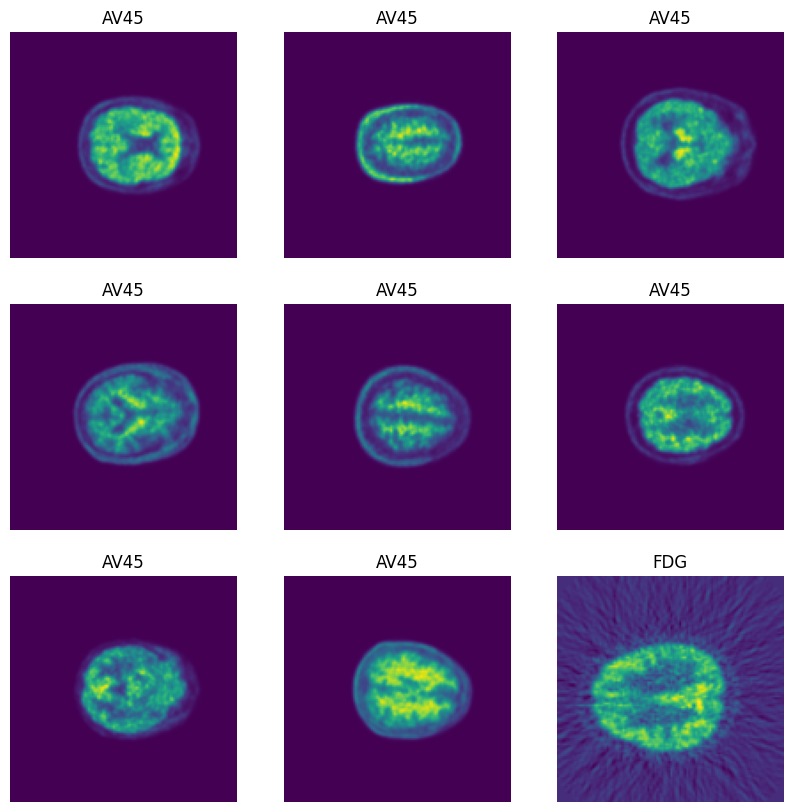

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [59]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 128, 128, 3)
(32,)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Check image max and min before and after
normalization_layer = layers.Rescaling(1./255)

In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

In [ ]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

In [ ]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()